In [5]:
# 주가 정보를 가져오기 위한 라이브러리 설치
!pip install yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.2/948.2 kB 22.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peewee: filename=peewee-3.17.8-py3-none-any.whl size=138964 sha256=3938a5f45506c03c68f90630cb3ca1fea90381d390b737141acb78afca1a37c0
  Stored in directory: /Users/bonheonkoo/Library/Caches/pip/wheels/75/79/e5/8838db0594cc6c587142fd2563356392ade6255c5930411069
Successfully built peewee

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [269]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import warnings
import time
import random
from   tqdm      import tqdm
import matplotlib.pyplot   as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import torch
import torch.nn                     as nn
import torch.optim                  as optim
import torch.nn.functional          as F
from   torch.utils.data             import Dataset,DataLoader

# SK하이닉스 데이터 가져오기
data = yf.download('000660.KS', start='2015-01-01', end='2024-12-11')

# 데이터 확인
print(data.head())

# 시드(seed) 고정
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
warnings.filterwarnings(action='ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

[*********************100%***********************]  1 of 1 completed

Price          Adj Close     Close      High       Low      Open    Volume
Ticker         000660.KS 000660.KS 000660.KS 000660.KS 000660.KS 000660.KS
Date                                                                      
2015-01-02  41929.367188   47750.0   48400.0   47650.0   47950.0   1155944
2015-01-05  41841.550781   47650.0   48400.0   47500.0   48050.0   1409146
2015-01-06  41709.843750   47500.0   47600.0   46900.0   47000.0   1661196
2015-01-07  41622.023438   47400.0   47600.0   46700.0   46700.0   1821266
2015-01-08  43861.187500   49950.0   50000.0   47900.0   48250.0   5006675
cpu


In [270]:
data.columns = ['Adj 종가', '종가', '고가', '저가', '시가', '거래량']
# 이동평균선 추가
data['MA_5'] = data['종가'].rolling(window=5).mean()
data['MA_20'] = data['종가'].rolling(window=20).mean()
data['MA_50'] = data['종가'].rolling(window=50).mean()
data['MA_200'] = data['종가'].rolling(window=200).mean()
data.reset_index(inplace=True)
data.drop(columns = ['Adj 종가'], inplace=True)

In [271]:
# 하이퍼 파라미터 설정
class Parameters():
    def __init__(self):
        self.description = 'LSTM 모델을 이용한 SK하이닉스 주가 예측'
        # 입력 시퀀스 길이 - look-back
        self.Lag         = 60
        # 예측 시퀀스 길이
        self.Horizon     = 1

        # 에포크 수
        self.epochs        = 500
        # 배치 크기
        self.batch_size    = 16
        # 학습률
        self.learning_rate = 1e-4 # 0.0001
        # 훈련된 모델 경로
        self.model_name    = 'LSTM'
        # 대상 시계열 이름
        self.targetSeries          = '종가'
        # 훈련 세트 비율
        self.TrainingSetPercentage = 0.90
        # 스케일링 {'Standard', 'MinMax', 'Robust'} 
        self.Scaling               = 'Standard'

args = Parameters()

In [272]:


# 'date' 열이 있다면 datetime 형식으로 변환
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])

# 데이터의 80%를 훈련 데이터로 사용하고 나머지는 테스트 데이터로 사용
idx = int(data.shape[0] * args.TrainingSetPercentage)

df_train = data[:idx].dropna().reset_index(drop=True)
df_test = data[idx:].dropna().reset_index(drop=True)

In [273]:
# 테스트 데이터의 시작 부분에 훈련 데이터의 마지막 'Lag' 행을 추가
df_test = pd.concat([df_train.iloc[-args.Lag:], df_test]).reset_index(drop=True)

# 스케일링할 피처 목록을 정의 ('date' 제외)
features_to_scale = data.columns.drop(['Date'])

# 스케일링 설정
if args.Scaling == 'MinMax':
    print('[INFO] Scaling: MinMax')
    scaler = MinMaxScaler()
elif args.Scaling == 'Robust':
    print('[INFO] Scaling: Robust')
    scaler = RobustScaler()
else:
    print('[INFO] Scaling: Standard')
    scaler = StandardScaler()

# 훈련 데이터에 스케일러를 핏
df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])

# 동일한 스케일러로 테스트 데이터를 변환
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])


[INFO] Scaling: Standard


In [274]:
# LSTM 모델을 위한 시퀀스를 생성합니다.
def create_dataset(df, Lag=1, Horizon=1, targetSeries=None, feature_cols=None):
    dataX, dataY, dataDate = [], [], []

    for i in tqdm(range(0, df.shape[0] + 1 - Lag - Horizon)):
        # 입력 시퀀스 X를 선택합니다.
        dataX.append(df[feature_cols].iloc[i:(i + Lag)].to_numpy())
        # 타겟 변수 y를 선택합니다.
        dataY.append(df[targetSeries].iloc[i + Lag : i + Lag + Horizon].to_numpy())
        # 참조를 위한 날짜를 저장합니다.
        dataDate.append(df['Date'].iloc[i + Lag : i + Lag + Horizon].tolist())

    return (np.array(dataX), np.array(dataY), np.array(dataDate))

# 피처 컬럼 목록을 정의합니다 ('date' 제외)
feature_cols = data.columns.drop(['Date'])

In [275]:
# 데이터셋을 생성합니다.
trainX, trainY, _ = create_dataset(df=df_train, Lag=args.Lag, Horizon=args.Horizon,
                                   targetSeries=args.targetSeries, feature_cols=feature_cols)

testX, testY, testDate = create_dataset(df=df_test, Lag=args.Lag, Horizon=args.Horizon,
                                        targetSeries=args.targetSeries, feature_cols=feature_cols)

100%|██████████| 245/245 [00:00<00:00, 4972.39it/s]


In [276]:
trainX.shape

(1937, 60, 9)

In [277]:
# 훈련 데이터의 마지막 10%를 검증 데이터로 사용합니다.
idx = int(0.9 * trainX.shape[0])

validX, validY = trainX[idx:], trainY[idx:]
trainX, trainY = trainX[:idx], trainY[:idx]

# 필요에 따라 Y의 차원을 확장합니다.
trainY = np.expand_dims(trainY, axis=-1)
validY = np.expand_dims(validY, axis=-1)
testY = np.expand_dims(testY, axis=-1)

# 데이터셋의 모양을 출력합니다.
print('Training data shape:   ', trainX.shape, trainY.shape)
print('Validation data shape: ', validX.shape, validY.shape)
print('Testing data shape:    ', testX.shape, testY.shape)

Training data shape:    (1743, 60, 9) (1743, 1, 1)
Validation data shape:  (194, 60, 9) (194, 1, 1)
Testing data shape:     (245, 60, 9) (245, 1, 1)


In [278]:
import torch
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):
    def __init__(self, X, Y):
        # 데이터를 torch.tensor로 변환하고 데이터 타입을 float32로 설정
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# 훈련 및 테스트 데이터로더 생성
#
train_ds = Data(trainX, trainY)
valid_ds = Data(validX, validY)
test_ds  = Data(testX,  testY)

# 데이터 로더 준비
#
train_dl = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=args.batch_size, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=args.batch_size, shuffle=False)

In [286]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 모델 정의
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=48, dense_units=64, dropout_prob=0.4):
        super(LSTMModel, self).__init__()
        self.model = nn.Sequential(
            nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, dense_units),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(dense_units, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.model[0](x)  # LSTM 레이어만 따로 처리
        x = self.model[1](lstm_out[:, -1, :])  # Dropout (LSTM 출력의 마지막 타임스텝 사용)
        x = self.model[2](x)  # Linear
        x = self.model[3](x)  # ReLU
        x = self.model[4](x)  # Dropout
        x = self.model[5](x)  # 최종 Linear
        return x

# 모델 생성
input_size = trainX.shape[2]  # 입력 특징 수
model = LSTMModel(input_size=input_size).to(device)

# 손실 함수와 옵티마이저
criterion = nn.L1Loss()  # MAE (Mean Absolute Error)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 데이터 로더 생성
train_dataset = TensorDataset(torch.tensor(trainX, dtype=torch.float32), torch.tensor(trainY, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(validX, dtype=torch.float32), torch.tensor(validY, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# 학습 루프
epochs = 150
best_val_loss = float('inf')

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            outputs = model(x_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Checkpoint 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'content/best_model.pth')
        print(f"Model checkpoint saved at epoch {epoch + 1}")

# 모델 로드 및 평가
model.load_state_dict(torch.load('content/best_model.pth'))
model.eval()

Epoch 1/150, Train Loss: 0.7224, Val Loss: 1.0380
Model checkpoint saved at epoch 1
Epoch 2/150, Train Loss: 0.7180, Val Loss: 1.0494
Epoch 3/150, Train Loss: 0.7170, Val Loss: 1.0176
Model checkpoint saved at epoch 3
Epoch 4/150, Train Loss: 0.7179, Val Loss: 1.0437
Epoch 5/150, Train Loss: 0.7191, Val Loss: 1.0465
Epoch 6/150, Train Loss: 0.7190, Val Loss: 1.0456
Epoch 7/150, Train Loss: 0.7175, Val Loss: 1.0213
Epoch 8/150, Train Loss: 0.7176, Val Loss: 1.0333
Epoch 9/150, Train Loss: 0.7195, Val Loss: 1.0167
Model checkpoint saved at epoch 9
Epoch 10/150, Train Loss: 0.7199, Val Loss: 1.0485
Epoch 11/150, Train Loss: 0.7191, Val Loss: 1.0274
Epoch 12/150, Train Loss: 0.7170, Val Loss: 1.0546
Epoch 13/150, Train Loss: 0.7186, Val Loss: 1.0021
Model checkpoint saved at epoch 13
Epoch 14/150, Train Loss: 0.7181, Val Loss: 1.0253
Epoch 15/150, Train Loss: 0.7203, Val Loss: 1.0299
Epoch 16/150, Train Loss: 0.7161, Val Loss: 1.0220
Epoch 17/150, Train Loss: 0.7212, Val Loss: 1.0106
Epoch

LSTMModel(
  (model): Sequential(
    (0): LSTM(9, 48, batch_first=True)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=48, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [288]:
# 최적 모델 로드
model.load_state_dict(torch.load("content/best_model.pth"))
model.eval()
print('[INFO] 최적 모델이 로드되었습니다.')

[INFO] 최적 모델이 로드되었습니다.


In [289]:
import numpy as np
import torch

# 테스트 데이터 예측
test_predictions = []
test_targets = []
with torch.no_grad():
    for data, target in tqdm(test_dl):
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        test_predictions.append(output.cpu().numpy())
        test_targets.append(target.cpu().numpy())

# 예측값과 실제값을 배열로 연결
test_predictions = np.concatenate(test_predictions, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

# 출력 형태 확인
print(f"Predictions shape: {test_predictions.shape}")
print(f"Targets shape: {test_targets.shape}")

# 필요한 경우 출력 차원 조정
test_predictions = test_predictions.reshape(-1, args.Horizon)
test_targets = test_targets.reshape(-1, args.Horizon)


100%|██████████| 16/16 [00:00<00:00, 497.57it/s]

Predictions shape: (245, 1)
Targets shape: (245, 1, 1)


In [290]:
# 피처의 수와 대상 변수의 인덱스 찾기
num_features = len(feature_cols)
feature_cols_list = list(feature_cols)
target_index = feature_cols_list.index(args.targetSeries)

# 예측값과 실제값을 평탄화
n_samples = test_predictions.shape[0]
test_predictions_flat = test_predictions.flatten().reshape(-1, 1)
test_targets_flat = test_targets.flatten().reshape(-1, 1)

# 역스케일링을 위한 배열 생성
pred_full = np.zeros((n_samples * args.Horizon, num_features))
target_full = np.zeros((n_samples * args.Horizon, num_features))

# 대상 변수 위치에 예측값과 실제값을 삽입
pred_full[:, target_index] = test_predictions_flat.squeeze()
target_full[:, target_index] = test_targets_flat.squeeze()

# 역스케일링 수행
pred_inv_flat = scaler.inverse_transform(pred_full)[:, target_index]
target_inv_flat = scaler.inverse_transform(target_full)[:, target_index]

# 원래 형태로 재조정
test_predictions_inv = pred_inv_flat.reshape(n_samples, args.Horizon)
test_targets_inv = target_inv_flat.reshape(n_samples, args.Horizon)


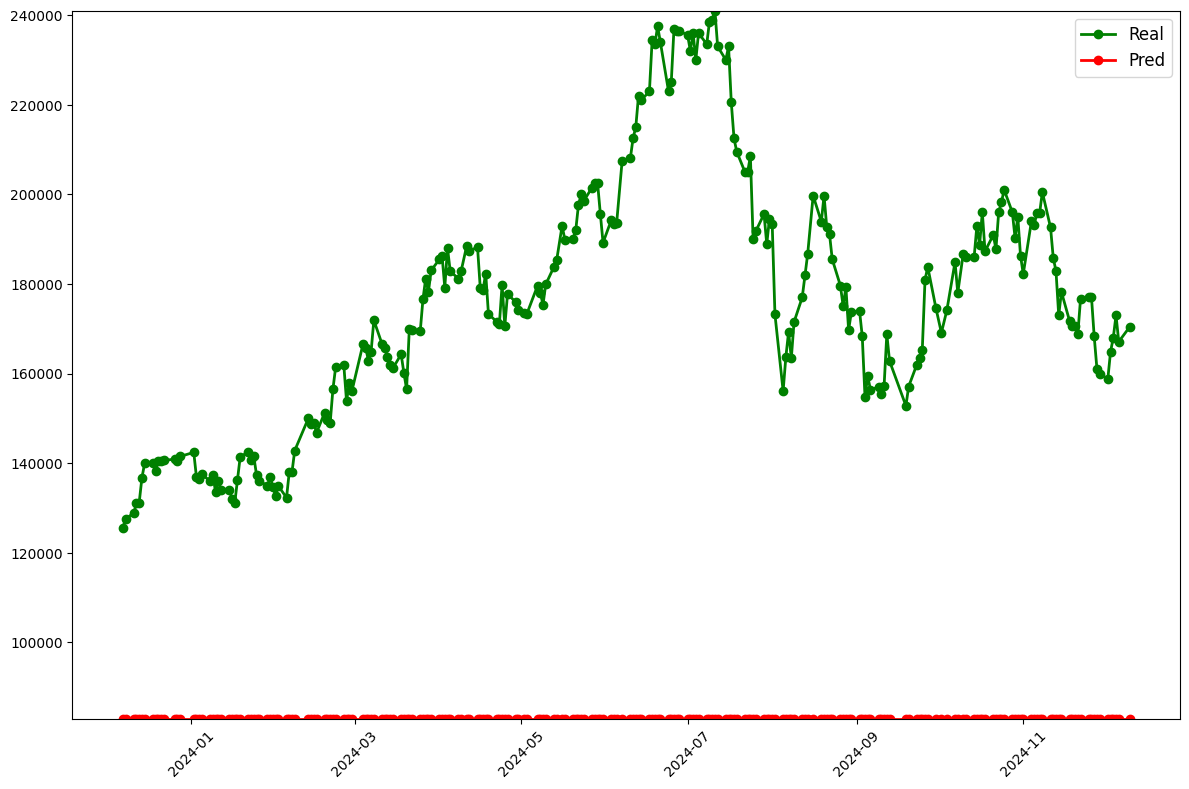

In [291]:
plt.figure(figsize = (12, 8))
plt.plot(testDate, test_targets_inv, color='g', marker='o', linewidth=2)
plt.plot(testDate, test_predictions_inv, color='r', marker='o', linewidth=2)

plt.legend(['Real', 'Pred'], fontsize=12)
plt.ylim([min(test_targets_inv.min(), test_predictions_inv.min()) - 10,
            max(test_targets_inv.max(), test_predictions_inv.max()) + 10])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

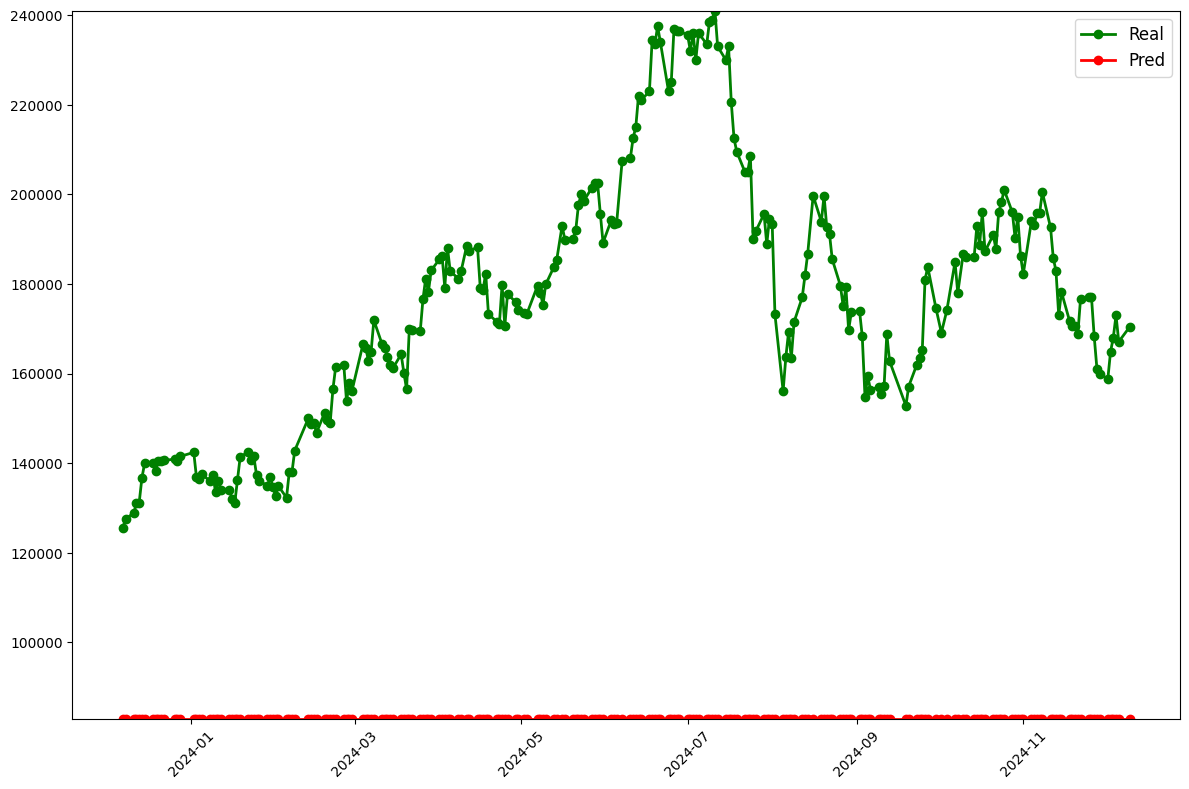

In [292]:
plt.figure(figsize = (12, 8))
plt.plot(testDate, test_targets_inv, color='g', marker='o', linewidth=2)
plt.plot(testDate, test_predictions_inv, color='r', marker='o', linewidth=2)

plt.legend(['Real', 'Pred'], fontsize=12)
plt.ylim([min(test_targets_inv.min(), test_predictions_inv.min()) - 10,
            max(test_targets_inv.max(), test_predictions_inv.max()) + 10])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()